In [1]:
import anndata as ad
import pandas as pd
import numpy as np

adata = ad.read_h5ad("/ddn_exa/campbell/sli/methyltrain/data/processed/CPTAC-3_adata.h5ad")

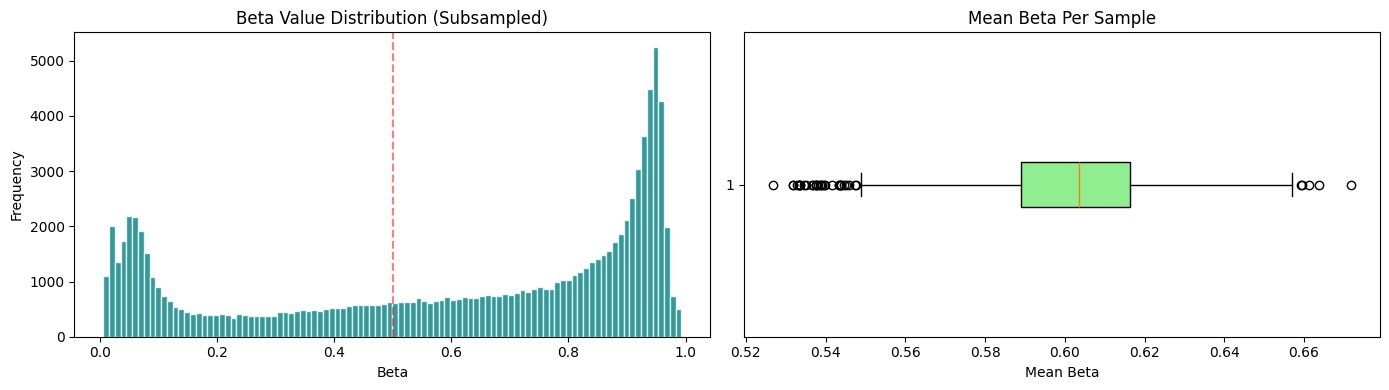

------------------------------
Total Probes: 413,180
Total Samples: 965
Global Range: [0.004, 0.996]
Missing Values: 0
------------------------------


In [2]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Efficient Data Sampling
# We take 100,000 random non-NaN data points for the histogram
raw_data = adata.X.flatten() if not hasattr(adata.X, 'toarray') else adata.X.data # Handles sparse/dense
clean_data = raw_data[~np.isnan(raw_data)]
sampled_betas = np.random.choice(clean_data, size=min(100000, len(clean_data)), replace=False)

# 2. Fast Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Beta Distribution Histogram
ax1.hist(sampled_betas, bins=100, color='teal', edgecolor='white', alpha=0.8)
ax1.set_title("Beta Value Distribution (Subsampled)")
ax1.set_xlabel("Beta")
ax1.set_ylabel("Frequency")
ax1.axvline(0.5, color='red', linestyle='--', alpha=0.5)

# Per-Sample Mean (Check for Batch/Outliers)
sample_means = np.nanmean(adata.X, axis=1)
ax2.boxplot(sample_means, vert=False, patch_artist=True, 
            boxprops=dict(facecolor='lightgreen'))
ax2.set_title("Mean Beta Per Sample")
ax2.set_xlabel("Mean Beta")

plt.tight_layout()
plt.show()

# 3. Quick Integrity Printout
print("-" * 30)
print(f"Total Probes: {adata.shape[1]:,}")
print(f"Total Samples: {adata.shape[0]}")
print(f"Global Range: [{np.nanmin(raw_data):.3f}, {np.nanmax(raw_data):.3f}]")
print(f"Missing Values: {np.isnan(raw_data).sum():,}")
print("-" * 30)